# Label Distribution

In [1]:
from pathlib import Path

# === Update these to match your dataset ===
INPUT_CSV = Path("/home/ubuntu/TW_MultiLabel_SMP/datasets/4000_Posts_Annotations - Combined_Dataset.csv")
OUTPUT_DIR = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op")

# Your column names in the CSV
TITLE_COL   = "title"         # title column
BODY_COL = "body"            # body column
LABELS_COL = "Tags"       # comma-separated labels

# Canonical label set (use your exact labels)
CANON_LABELS = [
    "Abuse", "Aggression", "Sexual", "Medical", "Mental Health",
    "Discrimination", "Pregnancy","Not Applicable"
]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("✅ Config set. Output dir:", OUTPUT_DIR.resolve())


✅ Config set. Output dir: /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op


In [2]:
import pandas as pd

df = pd.read_csv(INPUT_CSV)
print("Loaded dataframe shape:", df.shape)

# Sanity Check 
missing = [c for c in [TITLE_COL, BODY_COL, LABELS_COL] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Create a unified text column for downstream analyses
def _safe_str(x):
    return "" if pd.isna(x) else str(x)

df["text"] = df.apply(lambda r: (_safe_str(r[TITLE_COL]).strip() + " " + _safe_str(r[BODY_COL]).strip()).strip(), axis=1)

# Quick peek
display(df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].head(3))
print("Nulls per column:\n", df[[TITLE_COL, BODY_COL, "text", LABELS_COL]].isna().sum())


Loaded dataframe shape: (3994, 6)


,title,body,text,Tags
0,Complications after abortion?,"Hi everyone, Ive read that abortions don’t cau...","Complications after abortion? Hi everyone, Ive...","Medical, Pregnancy, Mental Health"
1,Second MA abortion today and I'm absolutely te...,I'm having my second MA abortion today and I'm...,Second MA abortion today and I'm absolutely te...,"Medical, Pregnancy, Mental Health"
2,Help needed/ live in Texas where abortion in b...,Anyone know of a legit site to support women i...,Help needed/ live in Texas where abortion in b...,Medical


Nulls per column:
 title    0
body     0
text     0
Tags     4
dtype: int64


In [3]:
from collections import Counter

def parse_label_list(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    # Split by comma; trim spaces
    return [t.strip() for t in str(x).split(",") if t.strip()]

df["labels_list"] = df[LABELS_COL].apply(parse_label_list)

# warn if any labels fall outside the canonical set
oov_counts = Counter(l for lst in df["labels_list"] for l in lst if l not in CANON_LABELS)
if oov_counts:
    print("⚠️ Found labels not in CANON_LABELS:", dict(oov_counts))
else:
    print("✅ All labels conform to CANON_LABELS")

display(df[[LABELS_COL, "labels_list"]].head(5))

✅ All labels conform to CANON_LABELS


,Tags,labels_list
0,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
1,"Medical, Pregnancy, Mental Health","[Medical, Pregnancy, Mental Health]"
2,Medical,[Medical]
3,Medical,[Medical]
4,"Pregnancy, Mental Health","[Pregnancy, Mental Health]"


In [4]:
def to_multi_hot(label_list, all_labels):
    return {f"y__{lab}": int(lab in label_list) for lab in all_labels}

mh = df["labels_list"].apply(lambda lst: to_multi_hot(lst, CANON_LABELS)).apply(pd.Series)

# ensure columns exist even if some labels never appear
for lab in CANON_LABELS:
    col = f"y__{lab}"
    if col not in mh.columns:
        mh[col] = 0

df = pd.concat([df, mh], axis=1)
df["has_any_label"] = df["labels_list"].apply(lambda lst: len(lst) > 0)

print("✅ Multi-hot columns added:", [c for c in df.columns if c.startswith("y__")][:5], "...")
display(df[[TITLE_COL, "text", "labels_list"] + [c for c in df.columns if c.startswith("y__")]].head(3))

✅ Multi-hot columns added: ['y__Abuse', 'y__Aggression', 'y__Sexual', 'y__Medical', 'y__Mental Health'] ...


,title,text,labels_list,y__Abuse,y__Aggression,y__Sexual,y__Medical,y__Mental Health,y__Discrimination,y__Pregnancy,y__Not Applicable
0,Complications after abortion?,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
1,Second MA abortion today and I'm absolutely te...,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]",0,0,0,1,1,0,1,0
2,Help needed/ live in Texas where abortion in b...,Help needed/ live in Texas where abortion in b...,[Medical],0,0,0,1,0,0,0,0


In [5]:
from itertools import combinations
from collections import Counter

# 5a) Label frequency
label_freq = (
    df[[c for c in df.columns if c.startswith("y__")]].sum(axis=0)
      .rename("count")
      .to_frame()
      .assign(label=lambda t: t.index.str.replace("^y__", "", regex=True))
      .loc[:, ["label", "count"]]
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5b) Pairwise co-occurrence (edge list)
pairs = Counter()
for lst in df["labels_list"]:
    if len(lst) >= 2:
        for a, b in combinations(sorted(lst), 2):
            pairs[(a, b)] += 1

coocc_df = (
    pd.DataFrame([{"label_a": a, "label_b": b, "count": c} for (a, b), c in pairs.items()])
      .sort_values("count", ascending=False)
      .reset_index(drop=True)
)

# 5c) Co-occurrence matrix (symmetric; diag = frequency)
coocc_matrix = pd.DataFrame(0, index=CANON_LABELS, columns=CANON_LABELS, dtype=int)
for (a, b), c in pairs.items():
    coocc_matrix.loc[a, b] = c
    coocc_matrix.loc[b, a] = c

for lab in CANON_LABELS:
    cnt = int(label_freq.loc[label_freq["label"] == lab, "count"].values[0]) if (label_freq["label"] == lab).any() else 0
    coocc_matrix.loc[lab, lab] = cnt

print("✅ Stats computed.")
display(label_freq.head(10))
display(coocc_df.head(10))
display(coocc_matrix.head())

✅ Stats computed.


,label,count
0,Mental Health,2842
1,Pregnancy,2125
2,Medical,1403
3,Abuse,1376
4,Sexual,701
5,Not Applicable,687
6,Discrimination,414
7,Aggression,160


,label_a,label_b,count
0,Mental Health,Pregnancy,1768
1,Medical,Pregnancy,1345
2,Abuse,Mental Health,1278
3,Medical,Mental Health,1132
4,Mental Health,Sexual,649
5,Abuse,Sexual,603
6,Discrimination,Mental Health,380
7,Discrimination,Pregnancy,248
8,Abuse,Pregnancy,242
9,Abuse,Discrimination,235


,Abuse,Aggression,Sexual,Medical,Mental Health,Discrimination,Pregnancy,Not Applicable
Abuse,1376,158,603,113,1278,235,242,0
Aggression,158,160,89,16,153,35,37,0
Sexual,603,89,701,101,649,87,151,0
Medical,113,16,101,1403,1132,135,1345,0
Mental Health,1278,153,649,1132,2842,380,1768,1


In [6]:
# === Cell 5B: All-size co-occurrence counts (k = 2..max) ===
# What & why:
# - Counts how often ANY subset of labels appears together in a post.
# - Example: counts for triples, quads, ... up to all labels present.
# - Outputs both a single table (all sizes) and separate CSVs per k.

from itertools import combinations
from collections import Counter
import pandas as pd

# Pull canonical labels and ensure we have labels_list
ALL_LABELS = CANON_LABELS

def itemset_counts_from_lists(label_lists, min_k=2, max_k=None):
    """
    Count frequency of all itemsets of size k in [min_k, max_k] across label_lists.
    Returns: dict k -> Counter({tuple(sorted(labels)): count})
    """
    max_len = max((len(lst) for lst in label_lists), default=0)
    if max_k is None:
        max_k = max_len
    k_to_counter = {k: Counter() for k in range(min_k, max_k + 1)}
    for lst in label_lists:
        unique = sorted(set(lst))  # avoid duplicates within a post
        for k in range(min_k, min(max_k, len(unique)) + 1):
            for comb in combinations(unique, k):
                k_to_counter[k][comb] += 1
    return k_to_counter

k_to_counts = itemset_counts_from_lists(df["labels_list"].tolist(), min_k=2)

# Flatten into a single DataFrame with columns: size_k, itemset (tuple), count
rows = []
for k, counter in k_to_counts.items():
    for itemset, c in counter.most_common():
        rows.append({"size_k": k, "itemset": itemset, "count": c})
coocc_all_sizes_df = pd.DataFrame(rows).sort_values(["size_k", "count"], ascending=[True, False]).reset_index(drop=True)

print("✅ Built all-size co-occurrence table.")
for k in sorted(coocc_all_sizes_df["size_k"].unique()):
    subset = coocc_all_sizes_df.query("size_k == @k")
    if not subset.empty:
        print(f"\n-- size_k = {k} (total {len(subset)} combinations) --")
        display(subset.head(3))

# Save: master + per-k CSVs
ALL_SIZES_PATH = OUTPUT_DIR / "label_cooccurrence_all_sizes.csv"
coocc_all_sizes_df.to_csv(ALL_SIZES_PATH, index=False)

# Also save separate files per k for convenience
for k, counter in k_to_counts.items():
    out = pd.DataFrame(
        [{"itemset": itemset, "count": c} for itemset, c in counter.most_common()]
    )
    out_path = OUTPUT_DIR / f"label_cooccurrence_k{k}.csv"
    out.to_csv(out_path, index=False)

print("✅ Saved:")
print(" -", ALL_SIZES_PATH.resolve())
for k in sorted(k_to_counts):
    print(" -", (OUTPUT_DIR / f"label_cooccurrence_k{k}.csv").resolve())

✅ Built all-size co-occurrence table.

-- size_k = 2 (total 23 combinations) --


,size_k,itemset,count
0,2,"(Mental Health, Pregnancy)",1768
1,2,"(Medical, Pregnancy)",1345
2,2,"(Abuse, Mental Health)",1278



-- size_k = 3 (total 36 combinations) --


,size_k,itemset,count
23,3,"(Medical, Mental Health, Pregnancy)",1087
24,3,"(Abuse, Mental Health, Sexual)",578
25,3,"(Abuse, Mental Health, Pregnancy)",232



-- size_k = 4 (total 35 combinations) --


...


-- size_k = 6 (total 7 combinations) --


,size_k,itemset,count
115,6,"(Abuse, Discrimination, Medical, Mental Health...",7
116,6,"(Abuse, Aggression, Discrimination, Medical, M...",6
117,6,"(Abuse, Aggression, Medical, Mental Health, Pr...",5



-- size_k = 7 (total 1 combinations) --


,size_k,itemset,count
122,7,"(Abuse, Aggression, Discrimination, Medical, M...",3


✅ Saved:
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_all_sizes.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k2.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k3.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k4.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k5.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k6.csv
 - /home/ubuntu/embeddings/linguistic_analysis_outputs/analysis_op/label_cooccurrence_k7.csv


### Label Dist. Histogram

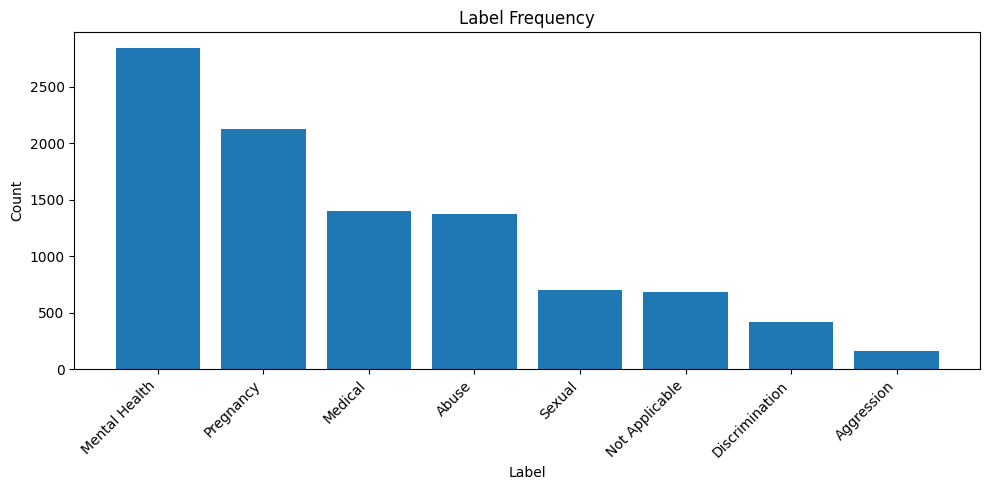

In [9]:
# === Cell 7: Bar chart for label frequencies ===
# What & why:
# - Visualizes how common each label is (sorted desc)
# - Helps you spot dominant or rare labels at a glance

import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# label_freq = pd.read_csv("./analysis_outputs/label_frequency.csv")

# Sort (should already be sorted, but just to be safe)
label_freq_plot = label_freq.sort_values("count", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.bar(label_freq_plot["label"], label_freq_plot["count"])
plt.title("Label Frequency")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Co-Occurence

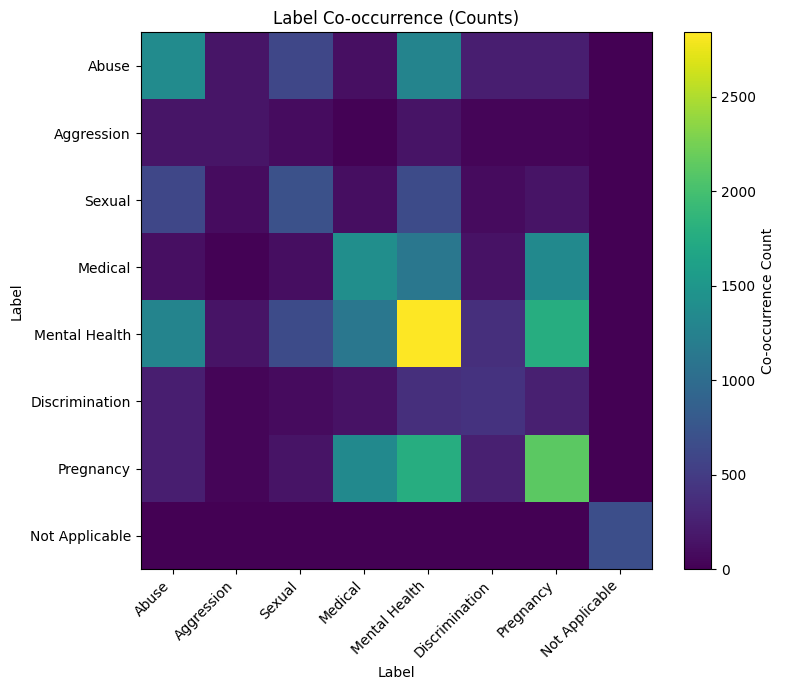

In [10]:
# === Cell 8: Co-occurrence heatmap ===
# What & why:
# - Shows which labels tend to appear together
# - Diagonal = individual label counts (handy as reference)
# - Off-diagonals = pair-wise co-occurrence counts

import numpy as np
import matplotlib.pyplot as plt

# If running in a fresh session (no memory), uncomment:
# import pandas as pd
# coocc_matrix = pd.read_csv("./analysis_outputs/label_cooccurrence_matrix.csv", index_col=0)

labels = list(coocc_matrix.index)
data = coocc_matrix.values.astype(float)

plt.figure(figsize=(8, 7))
im = plt.imshow(data, aspect="auto")  # default colormap
plt.title("Label Co-occurrence (Counts)")
plt.xlabel("Label")
plt.ylabel("Label")
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha="right")
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add a simple colorbar
cbar = plt.colorbar(im)
cbar.set_label("Co-occurrence Count")

plt.tight_layout()
plt.show()


### Correlation

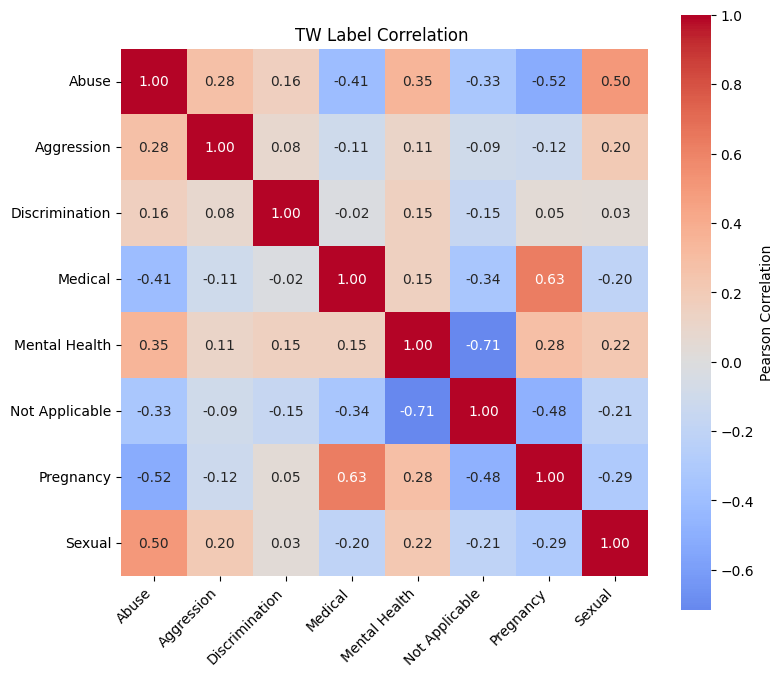

In [14]:
import seaborn as sns

df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# --- Create one-hot / multi-hot encoding ---
all_labels = sorted({lab for labs in df["labels_list"] for lab in labs})
for lab in all_labels:
    df[f"label_{lab}"] = df["labels_list"].apply(lambda labs: int(lab in labs))

label_df = df[[f"label_{lab}" for lab in all_labels]]

# --- Compute Pearson correlation ---
corr = label_df.corr(method="pearson")

# --- Plot ---
plt.figure(figsize=(8, 7))
sns.heatmap(
    corr,
    xticklabels=all_labels,
    yticklabels=all_labels,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Pearson Correlation"},
    fmt=".2f"
)
plt.title("TW Label Correlation ")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/home/ubuntu/.local/lib/python3.10/site-packages/upsetplot/data.py:303: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/ubuntu/.local/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=Tru

<Figure size 1000x600 with 0 Axes>

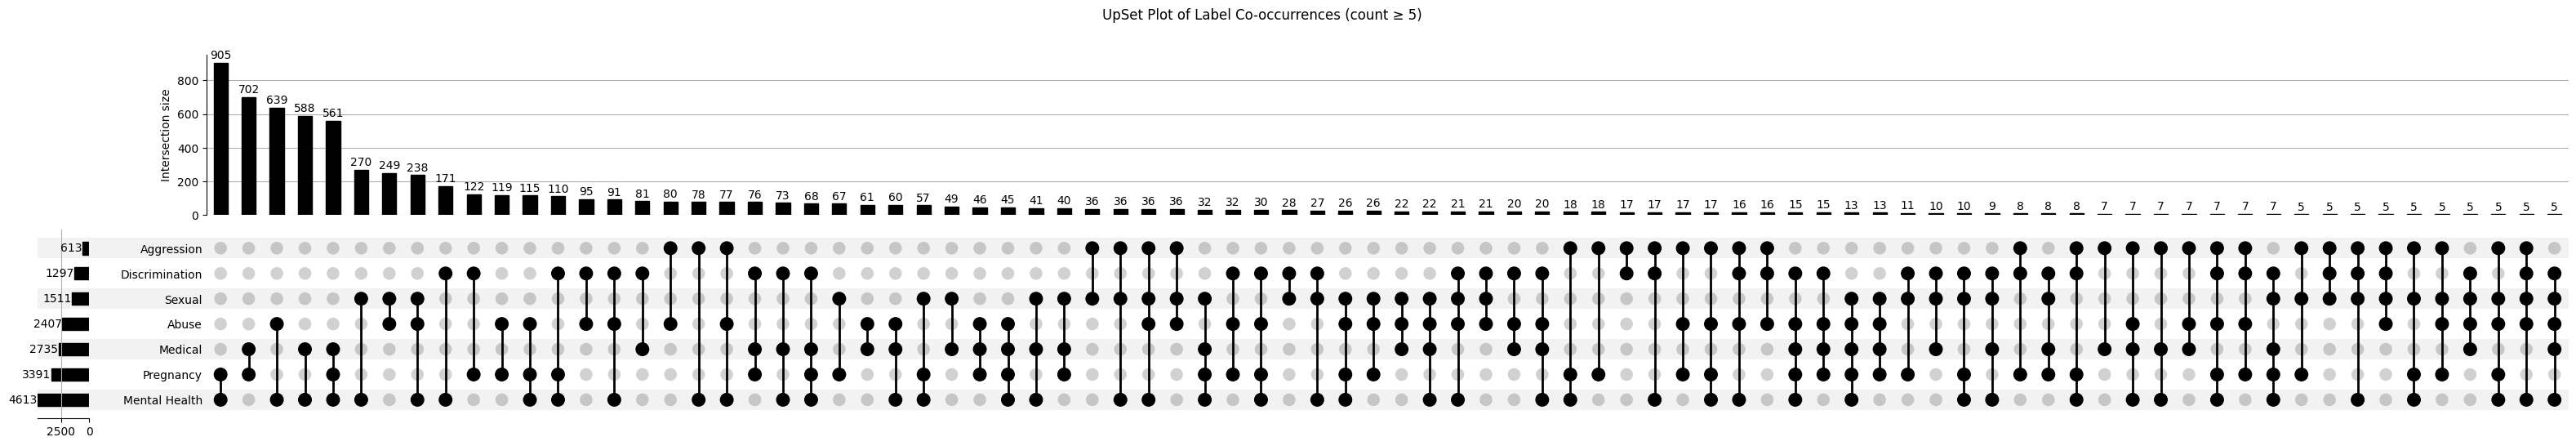

In [21]:
# === Cell 9: UpSet plot of frequent itemsets ===
# Shows intersections (any size) as bars; great for seeing which label combos are most common.

# !pip install upsetplot  # run once if needed

import pandas as pd
from upsetplot import UpSet, from_memberships
import matplotlib.pyplot as plt

# Choose a threshold so we don’t overwhelm the plot
MIN_COUNT_FOR_UPSET = 5  # tweak per your dataset size
subset = coocc_all_sizes_df[coocc_all_sizes_df["count"] >= MIN_COUNT_FOR_UPSET].copy()

if subset.empty:
    print("No itemsets meet the MIN_COUNT_FOR_UPSET threshold.")
else:
    # Convert tuples to list of strings for from_memberships
    memberships = subset["itemset"].apply(lambda t: list(t))
    data = from_memberships(memberships, data=subset["count"])

    plt.figure(figsize=(10, 6))
    UpSet(data, show_counts=True, sort_by='cardinality').plot()
    plt.suptitle("UpSet Plot of Label Co-occurrences (count ≥ {})".format(MIN_COUNT_FOR_UPSET))
    plt.show()

# Topic Modelling

In [9]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import pandas as pd
from pathlib import Path

In [10]:
import json, re
from collections import Counter
import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import nltk
from nltk.corpus import stopwords as nltk_stop
from tqdm import tqdm

In [11]:
TP_OUTPUT_DIR = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
TP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Paths set.")

✅ Paths set.


In [12]:
TEXT_COL = "text"

# Drop empty posts
df = df[df[TEXT_COL].notna() & (df[TEXT_COL].str.strip() != "")]
print("After dropping empty:", df.shape)

# Peek
display(df[[TEXT_COL, "labels_list"]].head(3))

After dropping empty: (3994, 17)


,text,labels_list
0,"Complications after abortion? Hi everyone, Ive...","[Medical, Pregnancy, Mental Health]"
1,Second MA abortion today and I'm absolutely te...,"[Medical, Pregnancy, Mental Health]"
2,Help needed/ live in Texas where abortion in b...,[Medical]


In [13]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

In [14]:
tqdm.pandas()

In [15]:
try:
    _ = nltk_stop.words("english")
except LookupError:
    import nltk; nltk.download("stopwords")

# 2) Base lists (general linguistic stopwords)
stop_spacy   = spacy.lang.en.stop_words.STOP_WORDS
stop_nltk    = set(nltk_stop.words("english"))
stop_sklearn = ENGLISH_STOP_WORDS
base_stop = set(stop_spacy) | stop_nltk | stop_sklearn

# 3) Domain/Reddit/informal fillers + contraction fragments
domain_stop = {
    # contractions & fragments (common after lemmatization)
    "im","ive","id","youre","theyre","weve","didn","doesn","wasn","werent","aint",
    "dont","didnt","doesnt","cant","couldnt","wouldnt","shouldnt","wont","arent",
    "ll","ve","re","d",
    # conversational fillers / light verbs / generic nouns
    "like","really","thing","things","stuff","lot","okay","ok","yeah","hmm","umm",
    "feel","felt","think","know","want","wanted","get","got","make","made","say","says","said",
    "people","person","one","someone","anyone","everyone","anything","something","everything","catherine",
    # web/reddit tokens
    "https","http","www","com","amp","reddit","r","u"
}

# 4) OPTIONAL: add top corpus-frequency noise (only if clearly non-content)
#    If you already have df["clean_text"], use that;
#    otherwise this will use df["text"] with minimal cleanup for a quick scan.
def quick_tokens(series):
    text = " ".join(series.astype(str).tolist()).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return [t for t in text.split() if len(t) > 2]

source_col = "clean_text" if "clean_text" in df.columns else "text"
most_common = Counter(quick_tokens(df[source_col])).most_common(40)

# Heuristic: add only obvious junky tops (edit this list after printing)
auto_add = {w for w, c in most_common if w in {
    "like","really","thing","things","stuff","people","got","said","say","know","think","want","make","made"
}}
domain_stop |= auto_add

# 5) Final hybrid list
custom_stopwords = base_stop | domain_stop
print(f"Hybrid stopwords size: {len(custom_stopwords)}")
print("Sample:", list(sorted(custom_stopwords))[:25])

# 6) Save to disk (so you can reuse)
STOP_PATH = "custom_stopwords.json"
with open(STOP_PATH, "w") as f:
    json.dump(sorted(list(custom_stopwords)), f, indent=2)
print(f"✅ Saved hybrid stopwords to {STOP_PATH}")

# 7) Helper to load later (if needed)
def load_custom_stopwords(path="custom_stopwords.json"):
    with open(path) as f:
        return set(json.load(f))

Hybrid stopwords size: 473
Sample: ["'d", "'ll", "'m", "'re", "'s", "'ve", 'a', 'about', 'above', 'across', 'after', 'afterwards', 'again', 'against', 'ain', 'aint', 'all', 'almost', 'alone', 'along', 'already', 'also', 'although', 'always', 'am']
✅ Saved hybrid stopwords to custom_stopwords.json


In [16]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|@\w+|<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if token.pos_ in {"NOUN","VERB","ADJ","ADV"} and token.lemma_ not in custom_stopwords
        and len(token.lemma_) > 2
        and not token.is_punct
        and not token.like_num
    ]
    return " ".join(tokens)

In [17]:
df["clean_text"] = df["text"].progress_apply(clean_text)
print("✅ Cleaned and lemmatized text ready for topic modeling.")

100%|██████████| 3994/3994 [01:34<00:00, 42.37it/s]

✅ Cleaned and lemmatized text ready for topic modeling.


In [28]:
# === Required imports for custom UMAP + HDBSCAN models ===
import umap
import hdbscan
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic

In [90]:
embedding_model = SentenceTransformer("all-mpnet-base-v2")  
# 2️⃣ Dimensionality reduction (UMAP)
umap_model = umap.UMAP(
    n_neighbors=15,         # local vs. global structure (10–50)
    n_components=5,         # dimensionality of the embedding space (default=5)
    min_dist=0.0,           # how tightly UMAP packs points (0.0 = dense)
    metric='cosine',        # cosine is best for sentence embeddings
    random_state=42
)

# 3️⃣ Clustering model (HDBSCAN)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15,    # same as min_topic_size for consistency
    metric='euclidean',     # metric used after UMAP
    cluster_selection_method='eom', 
    prediction_data=True
)

# 4️⃣ Create BERTopic model
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,               # plug in custom UMAP
    hdbscan_model=hdbscan_model,         # plug in custom HDBSCAN
    min_topic_size=15,                   # small enough to catch niche themes
    n_gram_range=(1, 2),                 # include bigrams
    top_n_words=10,                      # number of words per topic to show
    calculate_probabilities=True,        # enables topic probability output
    verbose=True,
    language="english",
    nr_topics='auto'
)

In [37]:
# texts = df[TEXT_COL].tolist()
# topics, probs = topic_model.fit_transform(texts)

# # Save results to df
# df["topic_id"] = topics
# df["topic_probability"] = probs

# # Summary of discovered topics
# topic_info = topic_model.get_topic_info()
# display(topic_info.head(10))
# print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

In [27]:
# topic_info = topic_model.get_topic_info()
# display(topic_info.head(10))

In [91]:
import numpy as np, json

MODEL_DIR        = TP_OUTPUT_DIR / "bertopic_model"
DOC_TOPICS_PATH  = TP_OUTPUT_DIR / "document_topics.csv"
TOPIC_INFO_PATH  = TP_OUTPUT_DIR / "topic_summary.csv"
PROB_NPY_PATH    = TP_OUTPUT_DIR / "document_topic_probas.npy"

# 1) Fit model (heavy step)
texts = df["clean_text"].astype(str).tolist()
topics, probs = topic_model.fit_transform(texts)   # make sure topic_model was created with calculate_probabilities=True

# 2) Put assignments into df (avoid 2D assignment bug)
df["topic_id"] = topics

probs = np.asarray(probs)          # shape: (N_docs, N_topics)
df["topic_prob_max"] = probs.max(axis=1)  # 1-D, safe

# Top-K topic ids/probs (always create top1..top3; fill NaN if fewer topics exist)
K = min(3, probs.shape[1])
topk_idx = np.argsort(-probs, axis=1)[:, :K]             # indices of top-K topics
topk_val = np.take_along_axis(probs, topk_idx, axis=1)   # their probabilities

df["top1_topic_id"]   = topk_idx[:, 0] if K >= 1 else np.nan
df["top1_topic_prob"] = topk_val[:, 0] if K >= 1 else np.nan
df["top2_topic_id"]   = topk_idx[:, 1] if K >= 2 else np.nan
df["top2_topic_prob"] = topk_val[:, 1] if K >= 2 else np.nan
df["top3_topic_id"]   = topk_idx[:, 2] if K >= 3 else np.nan
df["top3_topic_prob"] = topk_val[:, 2] if K >= 3 else np.nan

# Optional: store full probability vector sparsely as JSON (keeps all info in one column)
def sparse_json(row):
    nz = np.nonzero(row)[0]
    return json.dumps({int(i): float(row[i]) for i in nz})
df["topic_probs_json"] = [sparse_json(row) for row in probs]

# 3) Topic summary table
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))
print(f"Total unique topics (excluding -1 outliers): {(topic_info.Topic != -1).sum()}")

# 4) SAVE model + outputs immediately (so accidental reruns don’t matter)
topic_model.save(MODEL_DIR)
topic_info.to_csv(TOPIC_INFO_PATH, index=False)

export_cols = ["text","labels_list","topic_id","topic_prob_max",
               "top1_topic_id","top1_topic_prob",
               "top2_topic_id","top2_topic_prob",
               "top3_topic_id","top3_topic_prob",
               "topic_probs_json"]
existing_cols = [c for c in export_cols if c in df.columns]
df[existing_cols].to_csv(DOC_TOPICS_PATH, index=False)

np.save(PROB_NPY_PATH, probs)

print("\n✅ Saved:")
print(" - Model:", MODEL_DIR.resolve())
print(" - Topic summary:", TOPIC_INFO_PATH.resolve())
print(" - Document topics:", DOC_TOPICS_PATH.resolve())
print(" - Full prob matrix (.npy):", PROB_NPY_PATH.resolve())

2025-10-17 18:22:58,659 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/63 [00:00<?, ?it/s]

2025-10-17 18:27:05,444 - BERTopic - Embedding - Completed ✓
2025-10-17 18:27:05,446 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-17 18:27:14,914 - BERTopic - Dimensionality - Completed ✓
2025-10-17 18:27:14,916 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-17 18:27:15,024 - BERTopic - Cluster - Completed ✓
2025-10-17 18:27:15,026 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-10-17 18:27:15,966 - BERTopic - Representation - Completed ✓
2025-10-17 18:27:15,971 - BERTopic - Topic reduction - Reducing number of topics
2025-10-17 18:27:15,979 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-17 18:27:16,949 - BERTopic - Representation - Completed ✓
2025-10-17 18:27:16,956 - BERTopic - Topic reduction - Reduced number of topics from 2 to 2


,Topic,Count,Name,Representation,Representative_Docs
0,0,1968,0_tell_time_week_day,"[tell, time, week, day, year, friend, start, t...",[parent absolutely hate husband cautionary tal...
1,1,32,1_remove_removed_assault_assault remove,"[remove, removed, assault, assault remove, rem...","[removed, removed, remove]"


2025-10-17 18:27:17,099 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Total unique topics (excluding -1 outliers): 2

✅ Saved:
 - Model: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/bertopic_model
 - Topic summary: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/topic_summary.csv
 - Document topics: /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topics.csv
 - Full prob matrix (.npy): /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topic_probas.npy


In [92]:
BASE = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
df_doc = pd.read_csv(BASE/"document_topics.csv")
out_pct = (df_doc["topic_id"] == -1).mean()*100
print(f"Outliers (topic = -1): {out_pct:.1f}%   ({(df_doc['topic_id']==-1).sum()} of {len(df_doc)})")

Outliers (topic = -1): 0.0%   (0 of 2000)


In [98]:
from sklearn.feature_extraction.text import CountVectorizer

more_noise = {
    # timeline fillers
    "week","weeks","day","days","start","started","happen","happened","time","work",
    # scraping/moderation artifacts
    "remove","removed","story","post","thread","edit","deleted"
}

custom_stopwords |= set(more_noise)

texts = df["clean_text"].astype(str).tolist()

# ✅ Fix: convert set → list
vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),   # ✅ convert set to list
    ngram_range=(1, 2),
    min_df=0.003,                        # keep tokens that appear in ≥0.3% of docs
    max_df=0.80,                         # drop tokens in >80% of docs
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

# Re-extract topic words with the improved vectorizer
topic_model.update_topics(texts, vectorizer_model=vectorizer_model, n_gram_range=(1, 2))

topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

,Topic,Count,Name,Representation,Representative_Docs
0,0,1968,0_baby_come_abortion_pregnant,"[baby, come, abortion, pregnant, pregnancy, mi...",[parent absolutely hate husband cautionary tal...
1,1,32,1_abuser metoo_advice realize_affect look_assa...,"[abuser metoo, advice realize, affect look, as...","[removed, removed, remove]"


In [99]:
def topic_name(tm, t, topn=4):
    if t == -1: return "Outliers"
    words = [w for w,_ in tm.get_topic(t)[:topn]]
    return " / ".join(words)

topic_info["topic_name"] = topic_info["Topic"].apply(lambda t: topic_name(topic_model, t, 4))
topic_info = topic_info.rename(columns={"Count":"doc_count"})
display(topic_info[["Topic","topic_name","doc_count"]].head(15))

,Topic,topic_name,doc_count
0,0,baby / come / abortion / pregnant,1968
1,1,abuser metoo / advice realize / affect look / ...,32


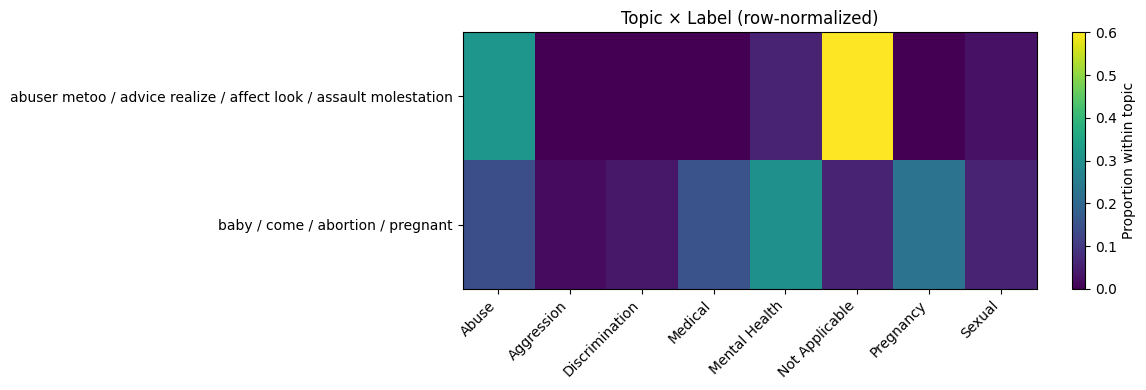

In [100]:
if isinstance(df_doc["labels_list"].iloc[0], str):
    df_doc["labels_list"] = df_doc["labels_list"].apply(eval)

# explode to one row per (doc, label)
exploded = df_doc.explode("labels_list")
exploded = exploded.rename(columns={"labels_list":"label"})

# counts per (topic, label)
ct = (exploded.groupby(["topic_id","label"]).size()
      .rename("count").reset_index())

# add topic names
name_map = dict(zip(topic_info["Topic"], topic_info["topic_name"]))
ct["topic_name"] = ct["topic_id"].map(name_map)

# make a pivot table for heatmap
pivot = ct.pivot_table(index="topic_name", columns="label", values="count", fill_value=0)
# normalize rows to proportions (optional; comment out if you want raw counts)
pivot_prop = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

plt.figure(figsize=(12, max(4, 0.5*len(pivot_prop))))
im = plt.imshow(pivot_prop.values, aspect="auto")
plt.yticks(range(len(pivot_prop.index)), pivot_prop.index)
plt.xticks(range(len(pivot_prop.columns)), pivot_prop.columns, rotation=45, ha="right")
plt.colorbar(im, label="Proportion within topic")
plt.title("Topic × Label (row-normalized)")
plt.tight_layout()
plt.show()

In [109]:
try:
    topic_model.visualize_barchart(top_n_topics=10).show()
    topic_model.visualize_topics().show()
except Exception as e:
    print("(Interactive viz may require notebook extension) ->", e)

(Interactive viz may require notebook extension) -> zero-size array to reduction operation maximum which has no identity


In [105]:
from pathlib import Path

BASE = Path("/home/ubuntu/embeddings/linguistic_analysis_outputs/topic_modeling_outputs")
MODEL_DIR2 = BASE / "bertopic_model_clean"    # new folder so original stays intact
TOPIC_INFO_CLEAN = BASE / "topic_summary_clean.csv"
DOC_TOPICS_CLEAN = BASE / "document_topics_clean.csv"

# Update df_doc topic ids if you changed them (reduce_outliers/reduce_topics)
# If you ran Step 3 with new_topics, persist them:
if 'new_topics' in locals():
    df_doc["topic_id"] = new_topics

# Recompute top1 topic after merges (optional but recommended)
# (You can skip if you don't need these columns here.)
# Note: If you want exact new probabilities, you'd call transform() to get new probs.

MODEL_DIR2.parent.mkdir(parents=True, exist_ok=True)
topic_model.save(MODEL_DIR2)
topic_info.to_csv(TOPIC_INFO_CLEAN, index=False)
df_doc.to_csv(DOC_TOPICS_CLEAN, index=False)

print("✅ Saved updated assets:")
print(" -", MODEL_DIR2.resolve())
print(" -", TOPIC_INFO_CLEAN.resolve())
print(" -", DOC_TOPICS_CLEAN.resolve())

2025-10-17 18:38:46,011 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Saved updated assets:
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/bertopic_model_clean
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/topic_summary_clean.csv
 - /home/ubuntu/TW_MultiLabel_SMP/datasets/linguistic_analysis_outputs/topic_modeling_outputs/document_topics_clean.csv


In [106]:
from collections import Counter
import numpy as np

def umass_coherence_for_topic(words, corpus_tokens, eps=1e-12):
    D = len(corpus_tokens)
    dfc = Counter()
    pc = Counter()
    for toks in corpus_tokens:
        uniq = set(toks)
        for w in uniq:
            dfc[w]+=1
        for i in range(1, len(words)):
            for j in range(i):
                if words[i] in uniq and words[j] in uniq:
                    pc[(words[i], words[j])] += 1
    score = 0.0; pairs=0
    for i in range(1, len(words)):
        for j in range(i):
            cw = pc[(words[i], words[j])]
            dw = dfc[words[j]]
            score += np.log((cw + eps) / (dw if dw>0 else 1))
            pairs += 1
    return score / max(pairs,1)

# lightweight tokenization
corpus_tokens = df["text"].str.lower().str.replace(r"[^a-z\s]", " ", regex=True).str.split()
coh = []
for t in topic_info.Topic[topic_info.Topic!=-1][:10]:
    words = [w for w,_ in topic_model.get_topic(t)[:10]]
    coh.append((t, umass_coherence_for_topic(words, corpus_tokens)))
print("UMass coherence (first 10 topics):")
for t, c in coh:
    print(f"Topic {t}: {c:.3f}")

UMass coherence (first 10 topics):
Topic 0: -1.441
Topic 1: -27.631


In [107]:
# explode labels and compute counts per (topic, label)
df_doc = pd.read_csv(BASE / "document_topics_clean.csv")
df_doc["labels_list"] = df_doc["labels_list"].apply(eval) if isinstance(df_doc["labels_list"].iloc[0], str) else df_doc["labels_list"]
df_ex = df_doc.explode("labels_list")

topic_label_counts = (df_ex.groupby(["topic_id","labels_list"])
                         .size().reset_index(name="count"))

# Normalize per-topic to proportions
topic_totals = topic_label_counts.groupby("topic_id")["count"].sum().rename("topic_total")
topic_label_props = topic_label_counts.merge(topic_totals, on="topic_id")
topic_label_props["prop"] = topic_label_props["count"] / topic_label_props["topic_total"]

topic_label_props.sort_values(["topic_id","prop"], ascending=[True,False]).head(20)

,topic_id,labels_list,count,topic_total,prop
4,0,Mental Health,1449,4798,0.302001
6,0,Pregnancy,1091,4798,0.227386
3,0,Medical,738,4798,0.153814
0,0,Abuse,686,4798,0.142976
7,0,Sexual,292,4798,0.060859
5,0,Not Applicable,275,4798,0.057316
2,0,Discrimination,186,4798,0.038766
1,0,Aggression,81,4798,0.016882
10,1,Not Applicable,21,35,0.600000
8,1,Abuse,11,35,0.314286


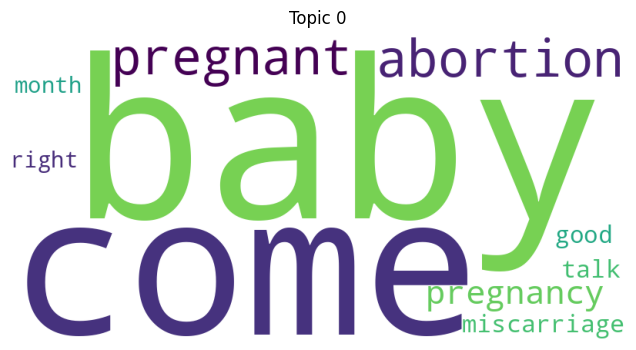

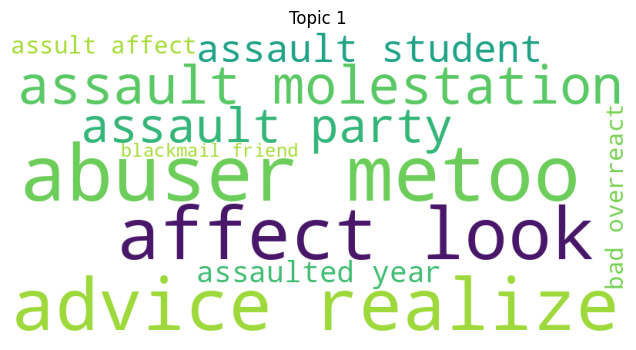

In [108]:
# !pip install wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for t in topic_info.Topic[topic_info.Topic!=-1].head(6):
    words = topic_model.get_topic(t)  # list of (word, weight)
    freqs = {w: float(s) for w,s in words}
    wc = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(freqs)
    plt.figure(figsize=(8,4)); plt.imshow(wc); plt.axis("off"); plt.title(f"Topic {t}")
    plt.show()

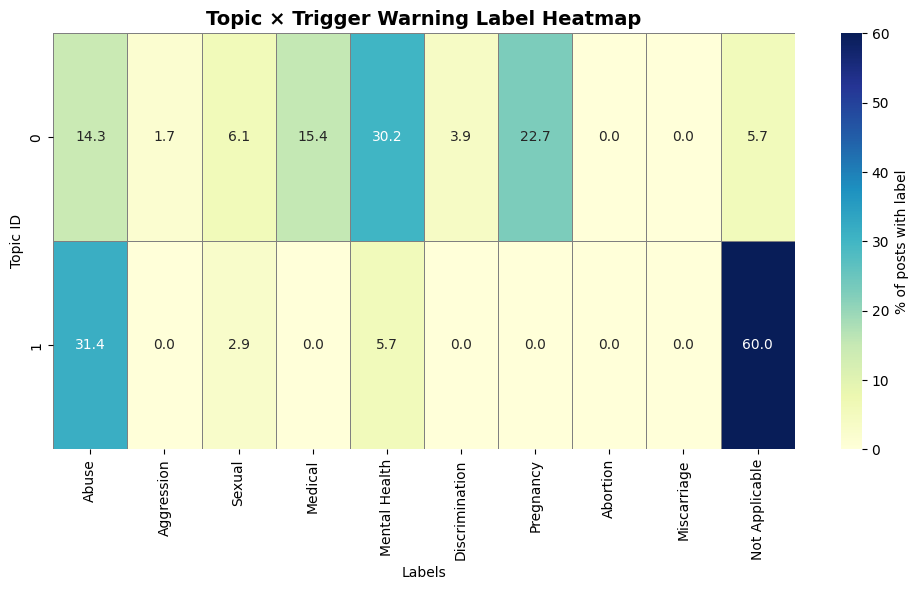

,Abuse,Aggression,Sexual,Medical,Mental Health,Discrimination,Pregnancy,Abortion,Miscarriage,Not Applicable
topic_id,,,,,,,,,,
0,14.3,1.7,6.1,15.4,30.2,3.9,22.7,0.0,0.0,5.7
1,31.4,0.0,2.9,0.0,5.7,0.0,0.0,0.0,0.0,60.0


In [111]:
# === TOPIC × LABEL HEATMAP ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# 1️⃣ Config
TOPIC_COL = "topic_id"
LABELS_COL = "Tags"   # change if your label column name differs
CANON_LABELS = [
    "Abuse", "Aggression", "Sexual", "Medical", "Mental Health",
    "Discrimination", "Pregnancy", "Abortion", "Miscarriage", "Not Applicable"
]

# 2️⃣ Prepare data
# Split multi-label strings into lists
df["labels_list"] = df[LABELS_COL].fillna("").apply(lambda x: [t.strip() for t in str(x).split(",") if t.strip()])

# Drop outliers (topic = -1)
df_no_outliers = df[df[TOPIC_COL] != -1].copy()

# 3️⃣ Count label occurrences per topic
topic_label_counts = []
for topic, group in df_no_outliers.groupby(TOPIC_COL):
    label_counts = Counter([lab for labs in group["labels_list"] for lab in labs])
    row = {lab: label_counts.get(lab, 0) for lab in CANON_LABELS}
    row["topic_id"] = topic
    topic_label_counts.append(row)

heat_df = pd.DataFrame(topic_label_counts).set_index("topic_id")

# 4️⃣ Normalize to percentages (optional, easier to interpret)
heat_df_pct = heat_df.div(heat_df.sum(axis=1), axis=0).fillna(0) * 100

# 5️⃣ Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heat_df_pct, annot=True, fmt=".1f", cmap="YlGnBu",
            cbar_kws={'label': '% of posts with label'},
            linewidths=0.5, linecolor="gray")
plt.title("Topic × Trigger Warning Label Heatmap", fontsize=14, weight="bold")
plt.xlabel("Labels")
plt.ylabel("Topic ID")
plt.tight_layout()
plt.show()

# 6️⃣ Optional: display underlying table
display(heat_df_pct.round(1))


In [112]:
def summarize_topic(tm, t, topn=6):
    if t == -1: return "Mixed/outlier posts that did not fit a dense cluster."
    words = [w for w,_ in tm.get_topic(t)[:topn]]
    return f"Posts discussing {words[0]}, {words[1]}, and {words[2]} — often involving {words[3]}, {words[4]}, {words[5]}."

summ_df = topic_info[topic_info.Topic!=-1].copy()
summ_df["summary"] = summ_df["Topic"].apply(lambda t: summarize_topic(topic_model, t))
display(summ_df[["Topic","topic_name","doc_count","summary"]].head(20))

,Topic,topic_name,doc_count,summary
0,0,baby / come / abortion / pregnant,1968,"Posts discussing baby, come, and abortion — of..."
1,1,abuser metoo / advice realize / affect look / ...,32,"Posts discussing abuser metoo, advice realize,..."


In [114]:
from collections import Counter

LABELS_COL = "Tags"  # change if needed
df["labels_list"] = df[LABELS_COL].fillna("").apply(lambda x: [t.strip() for t in str(x).split(",") if t.strip()])

rows = []
for topic, g in df[df["topic_id"]!=-1].groupby("topic_id"):
    c = Counter(l for labs in g["labels_list"] for l in labs)
    total = len(g)
    top_labels = ", ".join([f"{lab} ({c[lab]/total:.0%})" for lab,_ in c.most_common(3)])
    rows.append({
        "Topic": topic,
        "topic_name": topic_name(topic_model, topic),
        "docs": total,
        "top_labels": top_labels
    })
topic_label_view = pd.DataFrame(rows).sort_values("docs", ascending=False)
display(topic_label_view.head(20))

,Topic,topic_name,docs,top_labels
0,0,baby / come / abortion / pregnant,1968,"Mental Health (74%), Pregnancy (55%), Medical ..."
1,1,abuser metoo / advice realize / affect look / ...,32,"Not Applicable (66%), Abuse (34%), Mental Heal..."


## Top 3 Labels Topic Modelling

### Mental Health

In [25]:
LABEL_TO_ANALYZE = "Mental Health"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Mental Health: 2842 posts selected


In [26]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [31]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-10-22 04:08:42,873 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/89 [00:00<?, ?it/s]

2025-10-22 04:17:42,120 - BERTopic - Embedding - Completed ✓
2025-10-22 04:17:42,121 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 04:18:13,475 - BERTopic - Dimensionality - Completed ✓
2025-10-22 04:18:13,476 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 04:18:13,748 - BERTopic - Cluster - Completed ✓
2025-10-22 04:18:13,753 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 04:18:15,188 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,7,-1_denny_bipolar_bipolar disorder_academic,"[denny, bipolar, bipolar disorder, academic, m...",[trust love life experience hatred neglect gue...
1,0,1743,0_baby_pregnancy_miscarriage_test,"[baby, pregnancy, miscarriage, test, period, d...",[fetal pole heartbeat ultrasound angry doctor ...
2,1,1069,1_assault_guy_rape_uncomfortable,"[assault, guy, rape, uncomfortable, sexual ass...",[help possible throwaway boyfriend town cheat ...
3,2,23,2_catherine_husband_wife_baby,"[catherine, husband, wife, baby, cheater, sign...",[cheat wife wife year marry year originally re...


Topic 0:  baby, pregnancy, miscarriage, test, period, doctor, ultrasound, husband, pill, blood
Topic 1:  assault, guy, rape, uncomfortable, sexual assault, kiss, boyfriend, drunk, close, drink
Topic 2:  catherine, husband, wife, baby, cheater, significant, sil, cancer, marriage, chloe


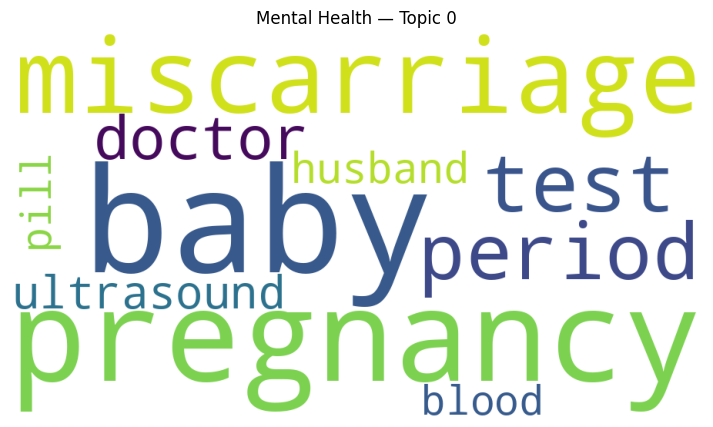

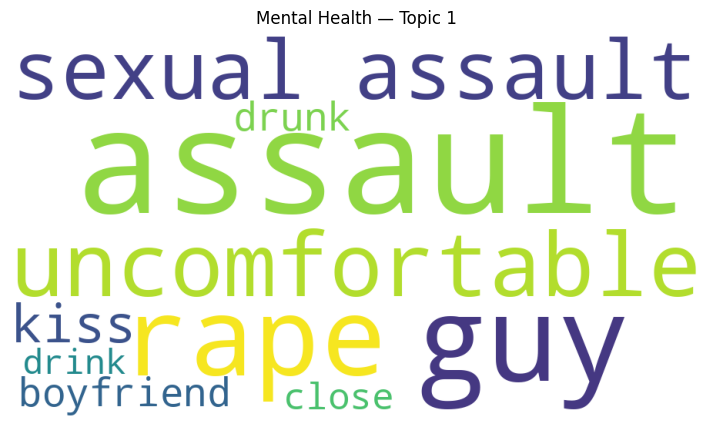

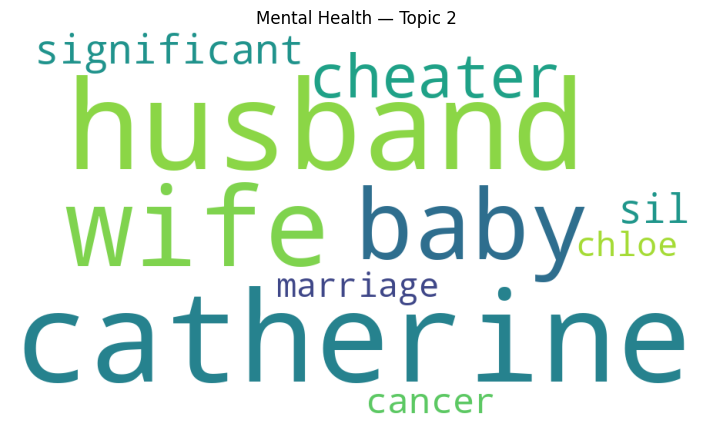

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_label_topic_wc(tid):
    freqs = {w: float(s) for w, s in topic_model_label.get_topic(tid)}
    wc = WordCloud(width=900, height=500, background_color="white",
                   stopwords=set(custom_stopwords))
    wc.generate_from_frequencies(freqs)
    plt.figure(figsize=(9,5)); plt.imshow(wc); plt.axis("off")
    plt.title(f"{LABEL_TO_ANALYZE} — Topic {tid}"); plt.show()

for tid in [t for t in topic_info_label.Topic if t != -1][:5]:
    plot_label_topic_wc(tid)

### Pregnancy

In [33]:
LABEL_TO_ANALYZE = "Pregnancy"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Pregnancy: 2125 posts selected


In [34]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [36]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-10-22 04:44:00,889 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/67 [00:00<?, ?it/s]

2025-10-22 04:47:48,083 - BERTopic - Embedding - Completed ✓
2025-10-22 04:47:48,084 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 04:47:58,187 - BERTopic - Dimensionality - Completed ✓
2025-10-22 04:47:58,188 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 04:47:58,318 - BERTopic - Cluster - Completed ✓
2025-10-22 04:47:58,323 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 04:47:59,249 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,118,-1_year_wedding_abortion_post,"[year, wedding, abortion, post, child, right, ...",[help need insight diagnose pco use overweight...
1,0,1952,0_abortion_year_life_right,"[abortion, year, life, right, child, ask, look...",[doctor sad abortion birth control fail throwa...
2,1,23,1_misoprostol_dose_pass_mifepristone,"[misoprostol, dose, pass, mifepristone, diarrh...",[drop post provide anecdote additional datum i...
3,2,18,2_dpo_thc_bleeding begin_pregnancy experience,"[dpo, thc, bleeding begin, pregnancy experienc...",[thc chew tobacco alcohol caffeine affect male...
4,3,14,3_dpo_faint_progesterone_drop,"[dpo, faint, progesterone, drop, negative, ass...",[bleed dpo good line progression follow chemic...


Topic 0:  abortion, year, life, right, child, ask, look, friend, husband, talk
Topic 1:  misoprostol, dose, pass, mifepristone, diarrhea, miso, tablet, follow, tissue, heavy bleeding
Topic 2:  dpo, thc, bleeding begin, pregnancy experience, sperm, line stop, week period, plateaue, begin day, heavy flow
Topic 3:  dpo, faint, progesterone, drop, negative, assume, dpiui, assume chemical, test positive, ovulation


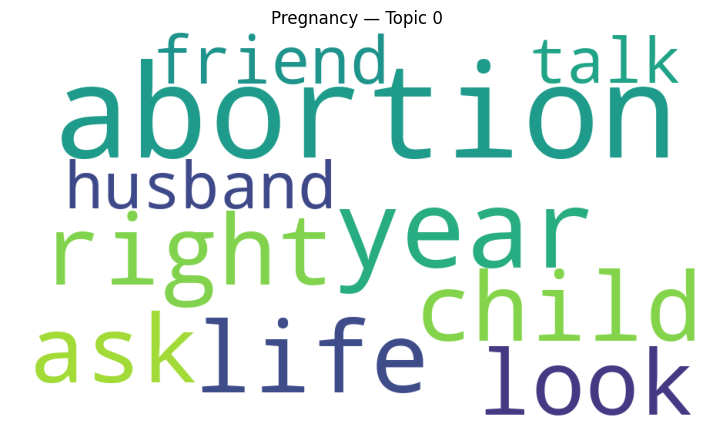

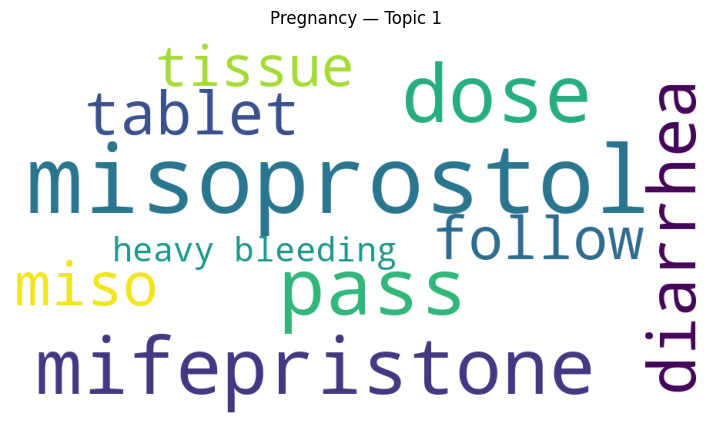

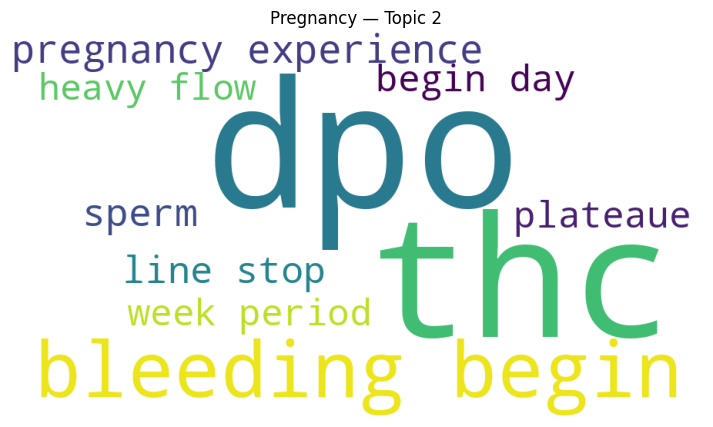

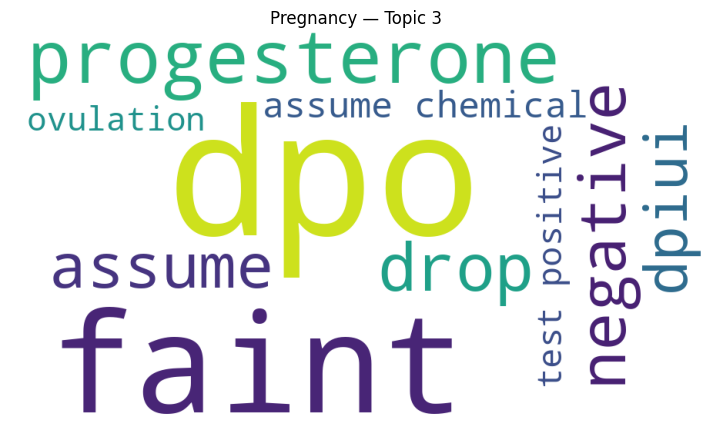

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_label_topic_wc(tid):
    freqs = {w: float(s) for w, s in topic_model_label.get_topic(tid)}
    wc = WordCloud(width=900, height=500, background_color="white",
                   stopwords=set(custom_stopwords))
    wc.generate_from_frequencies(freqs)
    plt.figure(figsize=(9,5)); plt.imshow(wc); plt.axis("off")
    plt.title(f"{LABEL_TO_ANALYZE} — Topic {tid}"); plt.show()

for tid in [t for t in topic_info_label.Topic if t != -1][:5]:
    plot_label_topic_wc(tid)

### Medical

In [38]:
LABEL_TO_ANALYZE = "Medical"   # change to any other label if needed

# Make sure labels are in list form
df["labels_list"] = df["Tags"].fillna("").apply(
    lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
)

# Filter rows that contain your target label
df_label = df[df["labels_list"].apply(lambda labs: LABEL_TO_ANALYZE in labs)].copy()

print(f"{LABEL_TO_ANALYZE}: {len(df_label)} posts selected")

Medical: 1403 posts selected


In [39]:
texts_label = df_label["clean_text"].astype(str).tolist()

In [40]:
from sklearn.feature_extraction.text import CountVectorizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

umap_model = umap.UMAP(
    n_neighbors=10,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=list(custom_stopwords),  # your hybrid stopword list
    ngram_range=(1, 2),
    min_df=0.003,
    max_df=0.8,
    token_pattern=r"(?u)\b[a-zA-Z][a-zA-Z]+\b"
)

topic_model_label = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    calculate_probabilities=True,
    verbose=True,
    min_topic_size=10,
    n_gram_range=(1,2),
    language="english"
)

In [41]:
topics_label, probs_label = topic_model_label.fit_transform(texts_label)

topic_info_label = topic_model_label.get_topic_info()
display(topic_info_label.head(10))

for t in topic_info_label.Topic.tolist():
    if t == -1: continue
    print(f"Topic {t}: ", ", ".join(w for w, _ in topic_model_label.get_topic(t)[:10]))

2025-10-22 04:49:58,483 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

2025-10-22 04:52:46,639 - BERTopic - Embedding - Completed ✓
2025-10-22 04:52:46,640 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 04:52:51,936 - BERTopic - Dimensionality - Completed ✓
2025-10-22 04:52:51,938 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 04:52:52,018 - BERTopic - Cluster - Completed ✓
2025-10-22 04:52:52,022 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 04:52:52,647 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,9,-1_bad_month_ovulation test_antibiotic,"[bad, month, ovulation test, antibiotic, terri...",[period previous post day super early week tod...
1,0,1346,0_baby_abortion_ultrasound_need,"[baby, abortion, ultrasound, need, year, pill,...",[miscarriage pharmacist refuse medication week...
2,1,18,1_hour_begin_thc_later,"[hour, begin, thc, later, bleeding begin, heav...",[thc chew tobacco alcohol caffeine affect male...
3,2,15,2_dpo_pregnancy test_progesterone_drop,"[dpo, pregnancy test, progesterone, drop, draw...",[worry ectopic wait test chemical pregnancy bl...
4,3,15,3_ovum_blighted_blighted ovum_blight,"[ovum, blighted, blighted ovum, blight, gestat...",[blight partner ivf experience bfp gestational...


Topic 0:  baby, abortion, ultrasound, need, year, pill, help, bad, happen, hour
Topic 1:  hour, begin, thc, later, bleeding begin, heavy, ectopic, dpo, pregnancy experience, sperm
Topic 2:  dpo, pregnancy test, progesterone, drop, draw, question, assume, assume chemical, dpiui, long
Topic 3:  ovum, blighted, blighted ovum, blight, gestational, sac, ectopic, gestational sac, ivf, schedule


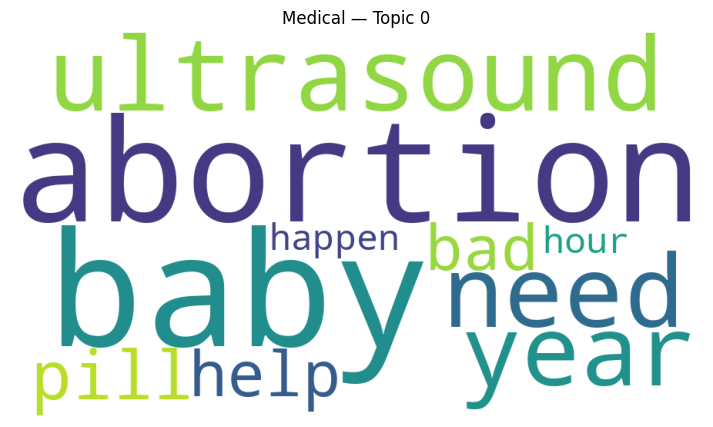

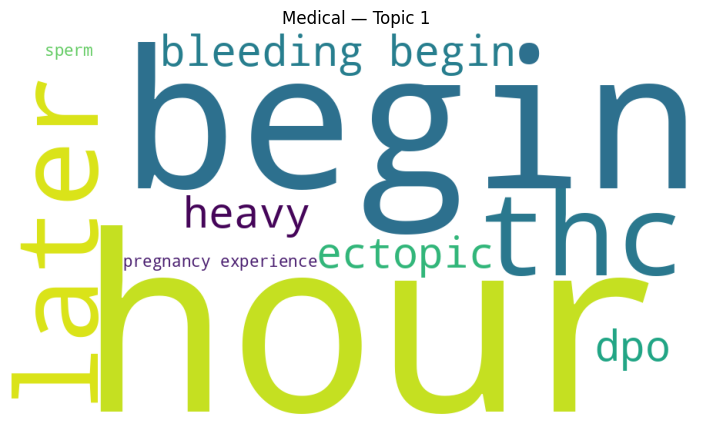

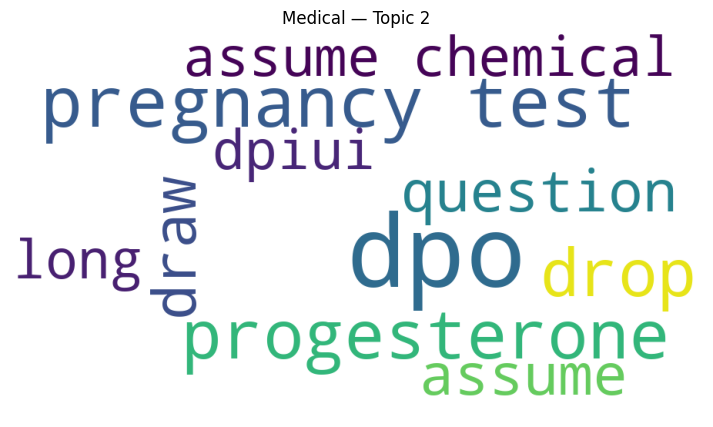

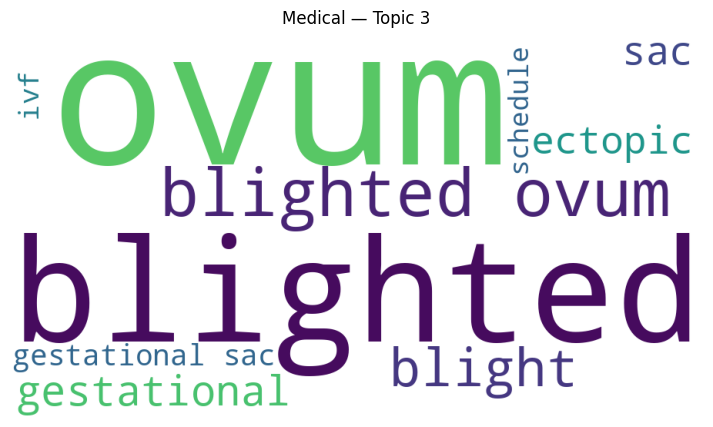

In [42]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_label_topic_wc(tid):
    freqs = {w: float(s) for w, s in topic_model_label.get_topic(tid)}
    wc = WordCloud(width=900, height=500, background_color="white",
                   stopwords=set(custom_stopwords))
    wc.generate_from_frequencies(freqs)
    plt.figure(figsize=(9,5)); plt.imshow(wc); plt.axis("off")
    plt.title(f"{LABEL_TO_ANALYZE} — Topic {tid}"); plt.show()

for tid in [t for t in topic_info_label.Topic if t != -1][:5]:
    plot_label_topic_wc(tid)

# LIWC

Dropping 194 stale Empath/duplicate columns: ['em_achievement', 'em_affection', 'em_aggression', 'em_air_travel', 'em_alcohol', 'em_ancient', 'em_anger', 'em_animal', 'em_anonymity', 'em_anticipation', 'em_appearance', 'em_art', 'em_attractive', 'em_banking', 'em_beach', 'em_beauty', 'em_blue_collar_job', 'em_body', 'em_breaking', 'em_business'] ...


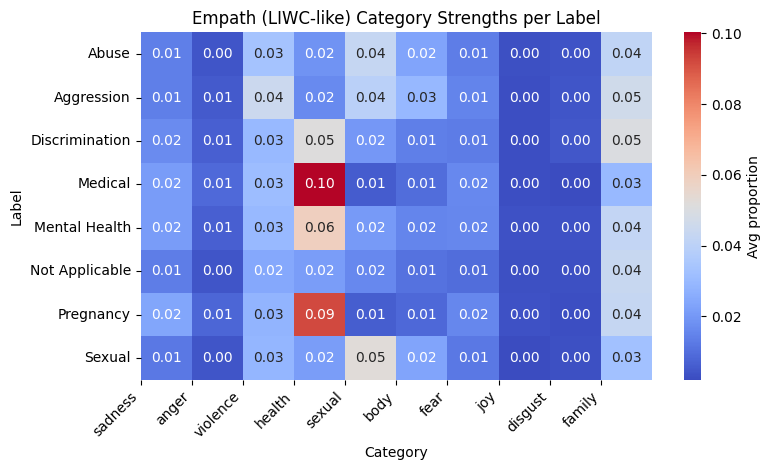

In [24]:
# === Repair duplicates, rebuild prefixed Empath features, plot heatmap ===
from empath import Empath
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt

lexicon = Empath()

LABELS_COL = "tags"  # <- adjust if different
TEXT_COL_USED = "clean_text" if "clean_text" in df.columns else "text"

# 0) Identify any prior (unprefixed) Empath category columns to drop
#    We generate a temp empath result to know the raw category names.
_tmp = pd.DataFrame([lexicon.analyze("test", normalize=True)])
raw_empath_cols = [c.strip().lower().replace(" ", "_") for c in _tmp.columns]

# 1) Normalize all current df column names once for matching
norm_map = {c: (c.strip().lower().replace(" ", "_") if isinstance(c, str) else c) for c in df.columns}
inv_map = {}
for k, v in norm_map.items():
    # keep first occurrence for inverse map
    inv_map.setdefault(v, k)

# 2) Build the set of columns to drop:
to_drop = set()
# a) any previous unprefixed empath cols (e.g., 'body','anger',...) if present
to_drop |= {inv_map[c] for c in raw_empath_cols if c in inv_map}
# b) any stale prefixed empath cols from earlier runs
to_drop |= {c for c in df.columns if isinstance(c, str) and c.startswith("em_")}
# c) never drop these core columns:
protect = {LABELS_COL, TEXT_COL_USED, "labels_list", "topic_id"}
to_drop -= protect

if to_drop:
    print(f"Dropping {len(to_drop)} stale Empath/duplicate columns:", sorted(map(str, to_drop))[:20], "...")
    df = df.drop(columns=list(to_drop), errors="ignore")

# 3) Recompute Empath per document
doc_scores = df[TEXT_COL_USED].fillna("").astype(str).apply(lambda t: lexicon.analyze(t, normalize=True))
empath_df = pd.DataFrame(doc_scores.tolist())
empath_df.columns = [f"em_{c.strip().lower().replace(' ', '_')}" for c in empath_df.columns]

# 4) Merge and enforce unique columns
df = df.reset_index(drop=True)
df = pd.concat([df, empath_df.reset_index(drop=True)], axis=1)
# ensure unique column names (keep first)
df = df.loc[:, ~df.columns.duplicated()]

# 5) Ensure labels_list exists
if "labels_list" not in df.columns:
    df["labels_list"] = df[LABELS_COL].fillna("").apply(
        lambda x: [t.strip() for t in str(x).split(",") if t.strip()]
    )

# 6) Choose Empath categories to visualize (prefixed)
desired = [
    "sadness", "anger", "violence", "health", 
    "sexual", "body", "fear", "joy", "disgust", "family"
]

avail = [f"em_{c}" for c in desired if f"em_{c}" in df.columns]

# Fallback: pick top-varying em_* if none of desired exist
if not avail:
    em_cols = [c for c in df.columns if isinstance(c, str) and c.startswith("em_") and pd.api.types.is_numeric_dtype(df[c])]
    var_rank = df[em_cols].var().sort_values(ascending=False)
    avail = var_rank.head(20).index.tolist()

missing = sorted(set(f"em_{c}" for c in desired) - set(avail))
if missing:
    print("ℹ️ Skipped missing categories:", [m.replace("em_","") for m in missing])

# 7) Aggregate by label and plot heatmap
expl = df.explode("labels_list")
heat = expl.groupby("labels_list")[avail].mean().sort_index()

plt.figure(figsize=(min(18, 2 + 0.6*len(avail)), 0.6*max(6, len(heat))))
sns.heatmap(
    heat,
    cmap="coolwarm",
    annot=True, fmt=".2f",
    cbar_kws={"label": "Avg proportion"}
)
plt.title("Empath (LIWC-like) Category Strengths per Label")
plt.xlabel("Category"); plt.ylabel("Label")
plt.xticks(ticks=range(len(avail)), labels=[c.replace("em_", "") for c in avail], rotation=45, ha="right")
plt.tight_layout(); plt.show()